> **Group:** Sara Martinez Rendon (1000424179) | Heider Zapata (1000009586) | Yeison Londoño (1000009479)  
> **Master's Degree in Data Sciences** | EAFIT University  
> **Course:** Applied Mathematics  
> **Date:** 24/02/2026
---

# **Examen 2 - Matemáticas Aplicadas en Ciencia de Datos**

---

## **Ejercicio 1**

---

## **Ejercicio 2**

> **En esta actividad trabajarás con imágenes de dígitos escritos a mano utilizando el conjunto de datos MNIST (disponible en Keras). Tu tarea es implementar un clasificador simple basado en la utilización del conceptos de álgebra lineal.**

Como primer paso, comprendamos el tipo de datos que vamos a manipular:


**¿Qué es MNIST?**

MNIST es una base de datos que contiene 70,000 imágenes pequeñas (de 28x28 píxeles). Cada imagen es un dígito del 0 al 9 escrito a mano por diferentes personas. Las imagenes están procesadas en una estructura de tensores (matrices multidimensionales):

| Objeto | Rol | Forma (Shape) | Rango de Valores | Descripción |
| :--- | :--- | :--- | :--- | :--- |
| **`x_train`** | Entrenamiento | `(60000, 28, 28)` | `0 - 255` | **Tensor 3D:** Un "bloque" de 60,000 matrices. Cada matriz representa una imagen (digito/numero dibujado) y está compuesta por $28 \times 28$ píxeles. Cada pixel indica el color o intensidad del lapiz (0: ausencia, 255: maxima presencia del trazo). |
| **`y_train`** | Entrenamiento | `(60000,)` | `0 - 9` | **Tensor 1D (Vector)** Contiene la etiqueta real (el número dibujado) para cada imagen del set de entrenamiento. La relación entre las imágenes dibujadas y sus etiquetas es implícita por su posición (índice). |
| **`x_test`** | Evaluación | `(10000, 28, 28)` | `0 - 255` | **Tensor 3D**: 10,000 imágenes adicionales que usaremos para validar la capacidad de generalización de nuestro clasificador |
| **`y_test`** | Evaluación | `(10000,)` | `0 - 9` | **Tensor 1D (Vector)**: Las etiquetas reales del set de prueba para medir el nivel de precisión del clasificador. |

Al ejecutar `(x_train, y_train), (x_test, y_test) = mnist.load_data()`, el módulo de TensorFlow descarga y organiza automáticamente los datos en estos cuatro objetos de tipo **NumPy Array**.


*Fuente: https://www.kaggle.com/datasets/hojjatk/mnist-dataset*

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 # Usaremos OpenCV para el reescalado
from tensorflow.keras.datasets import mnist 

# 1. Cargar el conjunto de datos MNIST
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

# Veriquemos dimensiones
print(f"X_train_full.shape: {X_train_full.shape}")
print(f"y_train_full.shape: {y_train_full.shape}")
print(f"X_test_full.shape: {X_test_full.shape}")
print(f"y_test_full.shape: {y_test_full.shape}")


# Veamos la matriz que representa la primera imagen (primer dígito) de X_train_full:
print("")
print("Primer digito en la matriz de entrenamiento (X_train_full[0]):")
#X_train_full[0] 
  # Usamos un for para que nos muestre cada número de la matriz (pixel) en un formato mas pequeño para
  # poder ver la matriz completa en un formato 28*28
for fila in X_train_full[0]:
    # Imprime cada número con 3 espacios de ancho para mantener la cuadrícula
    contenido_fila = "".join(f"{pixel:3}" for pixel in fila)
    print(contenido_fila)
    
#Veamos la primer etiqueta de y_train_full
print("")
print("Etiqueta de y_train_full[0]:", y_train_full[0])

X_train_full.shape: (60000, 28, 28)
y_train_full.shape: (60000,)
X_test_full.shape: (10000, 28, 28)
y_test_full.shape: (10000,)

Primer digito en la matriz de entrenamiento (X_train_full[0]):
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  3 18 18 18126136175 26166255247127  0  0  0  0
  0  0  0  0  0  0  0  0 30 36 94154170253253253253253225172253242195 64  0  0  0  0
  0  0  0  0  0  0  0 49238253253253253253253253253251 93 82 82 56 39  0  0  0  0  0
  0  0  0  0  0  0  0 18219253253253253253198182247241  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 80156107253253205 

### **2.1. Selección y Preprocesamiento de Datos:**

> * **Para cada dígito $d = 0, 1, . . . , 9$, selecciona aleatoriamente $k$ imágenes de entrenamiento. Esto te dará un conjunto de datos de tamaño $10 × k$.**

In [ ]:
# Definimos el parámetro k (número de imágenes por dígito)
# Usaremos un k pequeño inicial para poder visualizarlo fácilmente, luego lo podemos subir.
k = 5 

# Diccionario para almacenar las imágenes crudas (con 28x28 pixeles) seleccionadas
imagenes_crudas_k = {}

# Fijamos una semilla aleatoria para que el resultado sea reproducible
np.random.seed(42)

for d in range(10):
    # 1. Encontrar todos los índices en y_train_full que corresponden al dígito 'd' (0,1,2,...,9)
    indices_d = np.where(y_train_full == d)[0]
    
    # 2. Seleccionar aleatoriamente 'k' índices de esa lista, sin reemplazo
    indices_seleccionados = np.random.choice(indices_d, k, replace=False)
    
    # 3. Extraer las matrices (digitos de 28x28) correspondientes a esos índices
    # X_train_full[indices_seleccionados] nos devuelve un arreglo de forma (k, 28, 28)
    imagenes_crudas_k[d] = X_train_full[indices_seleccionados]

print(f"Diccionario creado. Contiene {len(imagenes_crudas_k)} llaves (una por dígito).")
print(f"Dimensiones de los datos guardados para el dígito 0: {imagenes_crudas_k[0].shape}")

Diccionario creado. Contiene 10 llaves (una por dígito).
Dimensiones de los datos guardados para el dígito 9: (5, 28, 28)


Confirmamos que para cada digito tenemos:

* 5 matrices (porque definimos $k = 5$ imágenes).
* Cada matriz tiene 28 filas.
* Cada matriz tiene 28 columnas.

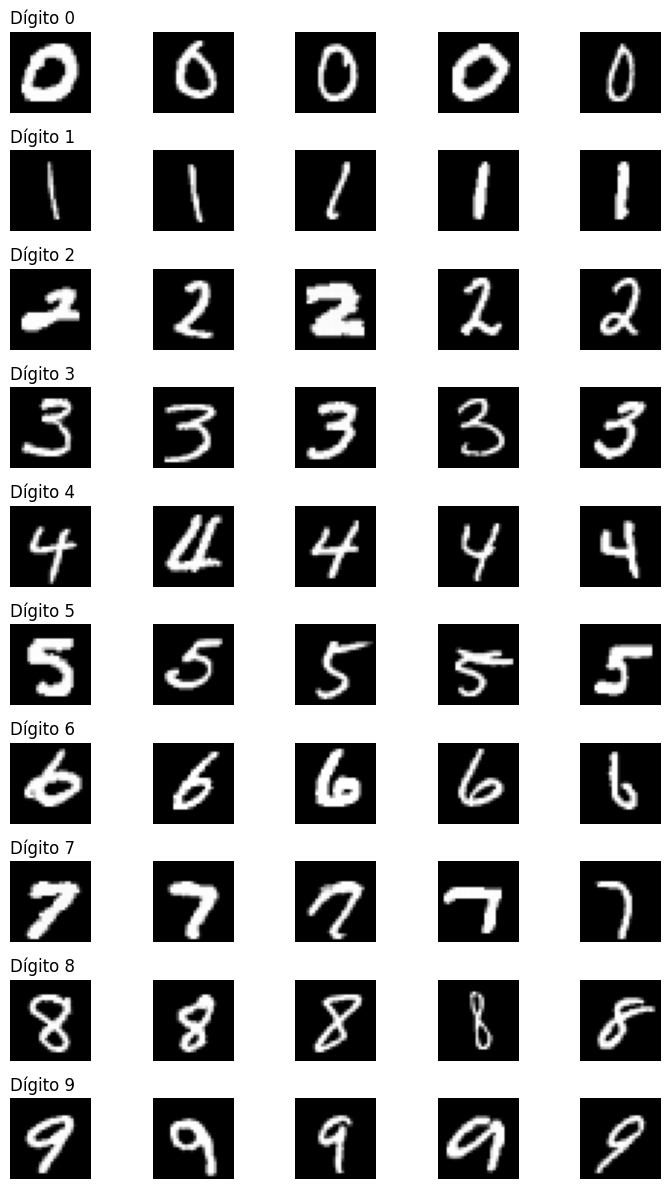

In [28]:
# --- Visualización del resultado del muestreo ---
# Vamos a graficar para confirmar que seleccionamos correctamente k imágenes de cada dígito
fig, axes = plt.subplots(10, k, figsize=(k * 1.5, 12))

for d in range(10):
    for i in range(k):
        # Seleccionamos el eje correspondiente
        ax = axes[d, i]
        # Mostramos la imagen (matriz 28x28)
        ax.imshow(imagenes_crudas_k[d][i], cmap='gray')
        ax.axis('off')
        
        # Ponemos el título solo en la primera columna para no saturar
        if i == 0:
            ax.set_title(f"Dígito {d}", loc='left')

plt.tight_layout()
plt.show()

Vemos que tenemos un conjunto de datos de $10 \times k$ => $10$ digitos con $k$ elementos cada uno ($k=5$)

Notése que no forzamos un único tensor global de dimensiones (10, k, 28, 28) ya que, al guardar las matrices de cada digito en un diccionario, ya tenemos los datos pre-agrupados por clase (dígito), lo cual nos servirá para luego calcular la base ortonormal $B_{d}$ de manera independiente para cada dígito.

>* **Convierte cada imagen a una matriz. Luego, recorta la imagen para eliminar las filas y columnas con únicamente el fondo (de modo que se preserve la mayor parte del dígito). Luego reescala la imagen resultante a un tamaño fijo de $16 × 16$ píxeles.**

Dado que las imágenes importadas ya se encuentran en formato matricial (arreglos de NumPy de 28x28) gracias a la librería de Keras (`mnist.load_data()`), entonces procedemos a eliminar la información redundante:

* **Recorte (Bounding Box)**: Eliminamos los bordes de fondo negro (píxeles con valor $0$). En álgebra lineal, estas áreas representan dimensiones con varianza nula que no aportan información para la clasificación. Para aislar la "señal" del "ruido", colapsamos la matriz bidimensional calculando el valor máximo a lo largo de sus ejes (filas y columnas). Esto nos permite identificar los índices exactos donde la intensidad del píxel deja de ser $0$ . Al recortar la matriz usando estos índices extremos (la caja delimitadora o bounding box), conservamos únicamente la región espacial que contiene la estructura topológica del dígito.

* **Reescalado**: Como cada dígito recortado tendrá un tamaño diferente (por ejemplo, un "1" suele ser más angosto que un "8"), estandarizamos todas las matrices resultantes a un tamaño espacial fijo de $16 \times 16$ píxeles utilizando la interpolación de OpenCV. Este paso es crucial porque, para poder operar algebraicamente con ellas (ej. construir las matrices $M_d$ y calcular la SVD), es estrictamente necesario que todas habiten en la misma dimensión geométrica.

**Nota:** ¿Por qué reescalar con cv2.INTER_AREA?

Porque usa promedio en lugar de eliminación: al reducir una imagen (downsampling), métodos básicos simplemente descartan píxeles, lo que podría "romper" o borrar las líneas delgadas de un dígito. INTER_AREA no elimina, sino que calcula un promedio ponderado de los píxeles que caen dentro de la nueva cuadrícula de 16x16. Al promediar áreas, se mantiene intacta la "masa" geométrica y la continuidad del trazo. Algebraicamente, esto garantiza que no perdamos la información original (la varianza) del número, lo cual es vital para que la SVD encuentre las bases latentes correctas en los siguientes pasos.


In [ ]:
# Diccionario para guardar las imágenes ya procesadas (recortadas y de 16x16)
imagenes_procesadas_k = {}

for d in range(10):
    lista_imagenes_procesadas = []
    
    for img in imagenes_crudas_k[d]:
        # 1. RECORTAR LA IMAGEN
        # Encontramos los índices de las filas y columnas que tienen al menos un pixel > 0
        filas_activas = np.where(img.max(axis=1) > 0)[0]
        cols_activas = np.where(img.max(axis=0) > 0)[0]
        
        # Validamos que la imagen no esté vacía (por seguridad)
        if len(filas_activas) > 0 and len(cols_activas) > 0:
            # Extraemos la sub-matriz que contiene solo el dígito
            recorte = img[filas_activas[0]:filas_activas[-1]+1, 
                          cols_activas[0]:cols_activas[-1]+1]
        else:
            recorte = img
            
        # 2. REESCALAR A 16x16
        # cv2.INTER_AREA es el método matemático más recomendado al reducir dimensiones de una imagen -> 
        reescalada = cv2.resize(recorte, (16, 16), interpolation=cv2.INTER_AREA)
        
        # normalizamos los valores entre 0 y 1 (paso ampliamente recomendado para tener mayor Estabilidad Numérica más adelante -> calcular descomposiciones (SVD), productos punto y normas (distancias)
        reescalada_norm = reescalada / 255.0
        
        lista_imagenes_procesadas.append(reescalada_norm)
        
    # Guardamos la lista de matrices 16x16 en el diccionario
    imagenes_procesadas_k[d] = lista_imagenes_procesadas

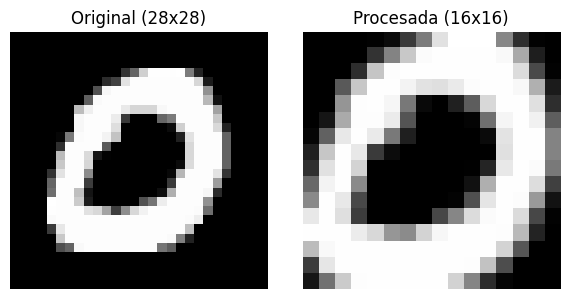

Dimensión de la matriz original: (28, 28)
Dimensión de la matriz procesada: (16, 16)


In [34]:
# --- Visualización del antes y después ---
# Tomemos el primer dígito (0) y su primera muestra [0] para comparar
img_original = imagenes_crudas_k[0][0]
img_procesada = imagenes_procesadas_k[0][0]

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(img_original, cmap='gray')
axes[0].set_title(f"Original (28x28)")
axes[0].axis('off')

axes[1].imshow(img_procesada, cmap='gray')
axes[1].set_title(f"Procesada (16x16)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Verificación de dimensiones
print(f"Dimensión de la matriz original: {img_original.shape}")
print(f"Dimensión de la matriz procesada: {img_procesada.shape}")

> * **Finalmente, convierte cada imagen reescalada a un vector de longitud $256$.**

¿Para qué aplanar cada matriz $16 \times 16$ a un vector de longitud $256$?

Para finalizar la fase de preprocesamiento, debemos transformar nuestra representación espacial en una representación puramente algebraica. Tomamos cada matriz bidimensional de $16 \times 16$ y concatenamos sus filas una detrás de otra para formar un único vector unidimensional. Geométricamente, esto significa que dejamos de tratar la imagen como una cuadrícula de píxeles y pasamos a entender cada imagen como un único vector (o punto) que habita en el espacio Euclidiano de 256 dimensiones ($\mathbb{R}^{256}$). Con este cambio, podremos desarrollar las operaciones de álgebra lineal de los siguientes puntos (como las proyecciones ortogonales por ejemplo).

In [36]:
# Diccionario para guardar exclusivamente los vectores aplanados
vectores_k = {}

for d in range(10):
    lista_vectores = []
    
    # Iteramos sobre las imágenes ya procesadas (16x16)
    for img_16x16 in imagenes_procesadas_k[d]:
        # Aplanar la matriz a un vector 1D de longitud 256
        vector = img_16x16.flatten() # .flatten() toma la matriz de cada imagen y lee sus elementos fila por fila, de izquierda a derecha, acomodándolos todos en una sola línea recta -> aplana la matriz a un vector
        lista_vectores.append(vector) #Este append nos servirá para que, al final del ciclo, lista_vectores contenga los k vectores individuales (uno por imagen/digito)
        
    # Guardamos la lista de vectores para este dígito
    vectores_k[d] = lista_vectores

# --- Control de Calidad ---
# Tomamos el primer vector del dígito 0 para verificar la transformación
vector_prueba = vectores_k[0][0]

print(f"Total de clases (dígitos) procesadas: {len(vectores_k)}")
print(f"Cantidad de vectores para el dígito 0: {len(vectores_k[0])} (esto es 'k')")
print(f"Dimensiones de un solo vector: {vector_prueba.shape}")

# Verificación matemática (16 * 16 = 256)
assert vector_prueba.shape[0] == 256, "Error: El vector no tiene exactamente 256 dimensiones."

Total de clases (dígitos) procesadas: 10
Cantidad de vectores para el dígito 0: 5 (esto es 'k')
Dimensiones de un solo vector: (256,)


**Análisis de la Estructura Resultante (vectores_k)**:

En este punto, nuestro conjunto de datos ha dejado de ser una colección visual de imágenes para convertirse formalmente en un conjunto de vectores algebraicos listos para el análisis de subespacios.

El objeto vectores_k almacena nuestro conjunto de entrenamiento estructurado de la siguiente manera:
* **Claves (Clases)**: Los números enteros del $0$ al $9$, representando cada uno de los dígitos a clasificar.
* **Valores (Muestras)**: Una lista que contiene exactamente $k$ elementos para cada clase.
* **Elementos (Vectores)**: Cada elemento de la lista es un vector unidimensional (arreglo numérico) perteneciente al espacio euclidiano $\mathbb{R}^{256}$.

Esta estructura agrupa las muestras (vectores -> imagenes -> digitos) por clase (Numeros del 0 al 9) de tal manera que facilita el siguiente paso algebraico: tomar los $k$ vectores individuales de cada dígito y concatenarlos horizontalmente para ensamblar las matrices de entrenamiento $M_{d} \in \mathbb{R}^{256 \times k}$.

### **2.2. Construcción de Bases Latentes:**

* Para cada dígito $d$, organiza los $k$ vectores resultantes en una matriz $M_{d}$ (donde cada columna
corresponde a una imagen).
* Para cada dígito calcula una base orto-normal del espacio vectorial generado por las columna
de $M_{d}$, denotemos a esa base como $B_{d}$ y llamemos a ese espacio generado $U_{d}$.
* ¿Cómo se puede interpretar el espacio generado por $B_{d}$ en palabras?


### 2.3. Clasificación de una Imagen Nueva:

* Toma una imagen de prueba (que no esté en el conjunto de entrenamiento) y apliquele el mismo proceso: recortar, reescalar a $16 × 16$ y convertir a un vector $q$ de longitud $256$.
* Para cada dígito $d$, calcula la proyección ortogonal de $q$ sobre el subespacio generado por $B_{d}$,
obteniendo el vector proyectado $p_{d}$.
* Define la distancia $dist(q, d) = ||q−p_{d}||$. Clasifica la imagen $q$ asignándole la etiqueta del dígito
$d$ que minimice esta distancia.

### 2.4. Evaluación y Análisis:

* Utiliza un conjunto de validación (imágenes de prueba distintas a las utilizadas para formar $M_{d}$) y evalúa el porcentaje de aciertos de tu clasificador.
* Repite la evaluación variando $k$ (el número de imágenes de entrenamiento por dígito) y grafica la precisión del clasificador en función de $k$.
* Reflexiona sobre el compromiso entre el tamaño del conjunto de entrenamiento (y, por ende,la calidad de la base $B_{d}$) y la precisión de la clasificación.
* Adicionalmente, discute qué ventajas e inconvenientes encuentras en este método de clasificación en comparación con otros enfoques que suelen usarse para clasificar estos dígitos. (aquí no debes implementar otros métodos, pero debes ser riguroso en tu argumentación, explorar las otras opciones existentes)

---

## **Ejercicio 3**

___